# 02 — Train & Compare 4 Plant Health Classifiers

**Models:**
- Decision Tree
- Random Forest
- Logistic Regression
- Gaussian Naive Bayes

**Dataset Split:**
- Train: 64% (tuning models)
- Validation: 16% (hyperparameter selection)
- Test: 20% (final evaluation)

**Features:** temperature, air_humidity, soil_moisture  
**Target:** health_status (3 classes: healthy, warning, critical)

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

DATA_DIR = Path('../dataset/raw')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

FEATURES = ['temperature', 'air_humidity', 'soil_moisture']
CLASS_NAMES = ['healthy', 'warning', 'critical']

print('Packages OK')

Packages OK


In [85]:
df = pd.read_csv(DATA_DIR / 'plant_health_processed.csv')
print(df.shape)
print(df['label'].value_counts())

X = df[FEATURES].values.astype(np.float32)
y = df['label'].values.astype(int)

unique = sorted(set(y))
if unique != list(range(len(unique))):
    remap = {old:new for new, old in enumerate(unique)}
    y = np.array([remap[v] for v in y])

n_classes = len(set(y))
names = CLASS_NAMES[:n_classes]

print(names)

(1200, 4)
label
2    500
1    401
0    299
Name: count, dtype: int64
['healthy', 'warning', 'critical']


In [86]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Ratios: {len(X_train)/len(X):.1%} | {len(X_val)/len(X):.1%} | {len(X_test)/len(X):.1%}')

Train: 768 | Val: 192 | Test: 240
Ratios: 64.0% | 16.0% | 20.0%


In [87]:
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_val_acc = accuracy_score(y_val, dt.predict(X_val))
dt_test_acc = accuracy_score(y_test, dt.predict(X_test))
dt_cv = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=StratifiedKFold(5),
    scoring='accuracy'
).mean()

print(f'Decision Tree - Train: {dt_train_acc:.4f} | Val: {dt_val_acc:.4f} | Test: {dt_test_acc:.4f} | CV: {dt_cv:.4f}')

Decision Tree - Train: 0.8828 | Val: 0.8750 | Test: 0.8167 | CV: 0.8555


In [88]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_val_acc = accuracy_score(y_val, rf.predict(X_val))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=StratifiedKFold(5),
    scoring='accuracy'
).mean()

print(f'Random Forest - Train: {rf_train_acc:.4f} | Val: {rf_val_acc:.4f} | Test: {rf_test_acc:.4f} | CV: {rf_cv:.4f}')

Random Forest - Train: 0.8958 | Val: 0.8906 | Test: 0.8500 | CV: 0.8671


In [89]:
lr = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

lr.fit(X_train, y_train)

lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_val_acc = accuracy_score(y_val, lr.predict(X_val))
lr_test_acc = accuracy_score(y_test, lr.predict(X_test))
lr_cv = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=StratifiedKFold(5),
    scoring='accuracy'
).mean()

print(f'Logistic Regression - Train: {lr_train_acc:.4f} | Val: {lr_val_acc:.4f} | Test: {lr_test_acc:.4f} | CV: {lr_cv:.4f}')

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_train_acc = accuracy_score(y_train, nb.predict(X_train))
nb_val_acc = accuracy_score(y_val, nb.predict(X_val))
nb_test_acc = accuracy_score(y_test, nb.predict(X_test))
nb_cv = cross_val_score(
    nb,
    X_train,
    y_train,
    cv=StratifiedKFold(5),
    scoring='accuracy'
).mean()

print(f'Gaussian NB - Train: {nb_train_acc:.4f} | Val: {nb_val_acc:.4f} | Test: {nb_test_acc:.4f} | CV: {nb_cv:.4f}')

Logistic Regression - Train: 0.7969 | Val: 0.8177 | Test: 0.7625 | CV: 0.7864
Gaussian NB - Train: 0.7826 | Val: 0.7917 | Test: 0.7500 | CV: 0.7787


In [90]:
results = pd.DataFrame(
    [
        {
            'model': 'Decision Tree',
            'train_acc': dt_train_acc,
            'val_acc': dt_val_acc,
            'test_acc': dt_test_acc,
            'cv_acc': float(dt_cv)
        },
        {
            'model': 'Random Forest',
            'train_acc': rf_train_acc,
            'val_acc': rf_val_acc,
            'test_acc': rf_test_acc,
            'cv_acc': float(rf_cv)
        },
        {
            'model': 'Logistic Regression',
            'train_acc': lr_train_acc,
            'val_acc': lr_val_acc,
            'test_acc': lr_test_acc,
            'cv_acc': float(lr_cv)
        },
        {
            'model': 'Gaussian NB',
            'train_acc': nb_train_acc,
            'val_acc': nb_val_acc,
            'test_acc': nb_test_acc,
            'cv_acc': float(nb_cv)
        },
    ]
)

results = results.sort_values('test_acc', ascending=False)

print('\n' + '='*80)
print('MODEL COMPARISON - Sorted by Test Accuracy')
print('='*80)
print(results.to_string(index=False))
print('='*80)


MODEL COMPARISON - Sorted by Test Accuracy
              model  train_acc  val_acc  test_acc   cv_acc
      Random Forest   0.895833 0.890625  0.850000 0.867142
      Decision Tree   0.882812 0.875000  0.816667 0.855471
Logistic Regression   0.796875 0.817708  0.762500 0.786419
        Gaussian NB   0.782552 0.791667  0.750000 0.778652



Best Model (by validation accuracy): Random Forest
Test Accuracy: 0.8500

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

     healthy      0.750     1.000     0.857        60
     warning      0.818     0.900     0.857        80
    critical      1.000     0.720     0.837       100

    accuracy                          0.850       240
   macro avg      0.856     0.873     0.850       240
weighted avg      0.877     0.850     0.849       240



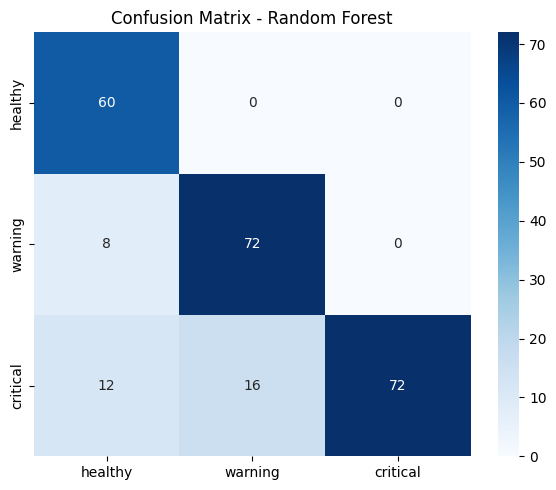

In [91]:
# Detailed analysis on validation set to select best model
best_model_idx = results.index[0]
best_model_name = results.loc[best_model_idx, 'model']

print(f'\nBest Model (by validation accuracy): {best_model_name}')
print(f'Test Accuracy: {results.loc[best_model_idx, "test_acc"]:.4f}')

# Get predictions from all models on test set
models = {'Decision Tree': dt, 'Random Forest': rf, 'Logistic Regression': lr, 'Gaussian NB': nb}
best_clf = models[best_model_name]

y_pred = best_clf.predict(X_test)

print(f'\n--- Classification Report ({best_model_name}) ---')
print(classification_report(
    y_test,
    y_pred,
    target_names=names,
    digits=3
))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=names,
    yticklabels=names,
    ax=ax
)
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

In [92]:
# Select best model and export
best_model_idx = results.index[0]
best_model_name = results.loc[best_model_idx, 'model']

print(f'\nBEST MODEL: {best_model_name}')
print(results.to_string(index=False))
print(f'\nTest Accuracy: {results.loc[best_model_idx, "test_acc"]:.4f}')
print(f'CV Accuracy: {results.loc[best_model_idx, "cv_acc"]:.4f}')


BEST MODEL: Random Forest
              model  train_acc  val_acc  test_acc   cv_acc
      Random Forest   0.895833 0.890625  0.850000 0.867142
      Decision Tree   0.882812 0.875000  0.816667 0.855471
Logistic Regression   0.796875 0.817708  0.762500 0.786419
        Gaussian NB   0.782552 0.791667  0.750000 0.778652

Test Accuracy: 0.8500
CV Accuracy: 0.8671


In [93]:
SELECTED_MODEL = best_model_name  # Auto-selected as best model. Change if you want to export a different one.

all_models = {
    'Decision Tree': (dt, False),
    'Random Forest': (rf, False),
    'Logistic Regression': (lr, True),
    'Gaussian NB': (nb, False)
}

selected_clf, _ = all_models[SELECTED_MODEL]

selected_clf.fit(X_temp, y_temp)

final_acc = accuracy_score(y_test, selected_clf.predict(X_test))

model_meta = {
    'model': selected_clf,
    'model_name': SELECTED_MODEL,
    'features': FEATURES,
    'class_names': names,
    'n_classes': n_classes,
    'test_accuracy': float(final_acc),
}

pkl_path = MODELS_DIR / 'plant_classifier.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_meta, f)

print(f'Saved: {pkl_path}')
print(f'Model: {SELECTED_MODEL}')
print(f'Test Accuracy: {final_acc:.4f}')
print(f'\nNext: Run 03_export_to_c.ipynb to export {SELECTED_MODEL} to C code')

Saved: ../models/plant_classifier.pkl
Model: Random Forest
Test Accuracy: 0.8500

Next: Run 03_export_to_c.ipynb to export Random Forest to C code


# Step 3: Export Selected Model to .pkl

Change `SELECTED_MODEL` below to export the best model (or any of the 4) to pickle file.